Project Scenario
Smart Traffic Sign Recognition System
Scenario
A city is building a Smart Traffic Monitoring System to improve road safety.

Every intersection in the city will have cameras that detect traffic signs automatically.

The system must recognize different road signs such as:

Stop sign

Speed limit sign

Pedestrian crossing sign

The system will be used in autonomous vehicles and traffic monitoring cameras.

However, the engineers discovered two challenges:

1️⃣ First, the system must understand basic classification logic (learning from features).
2️⃣ Second, it must classify images of traffic signs captured by cameras.

To solve this, the engineering team decided to build the system in two stages.

Stage 1
Learning Basic Neural Networks (Perceptron)
Before building a full image model, the engineers want students to first implement a Perceptron-based neural network to understand how neural networks make decisions.

The perceptron will predict whether a traffic sign means "STOP" or "NOT STOP" using extracted features.



Dataset is available in DatasetCapstoneProject4 in the github repo link https://github.com/himanshusar123/Datasets

   Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  Edge_Count  \
0        1                 0.90               0             1           8   
1        2                 0.20               1             0           4   
2        3                 0.85               0             1           7   
3        4                 0.30               1             0           5   
4        5                 0.88               0             1           8   

   Stop_Sign  
0          1  
1          0  
2          1  
3          0  
4          1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sign_ID              10 non-null     int64  
 1   Red_Color_Intensity  10 non-null     float64
 2   Circular_Shape       10 non-null     int64  
 3   Text_Present         10 non-null     int64  
 4   Edge_Count           10 non-null     int6

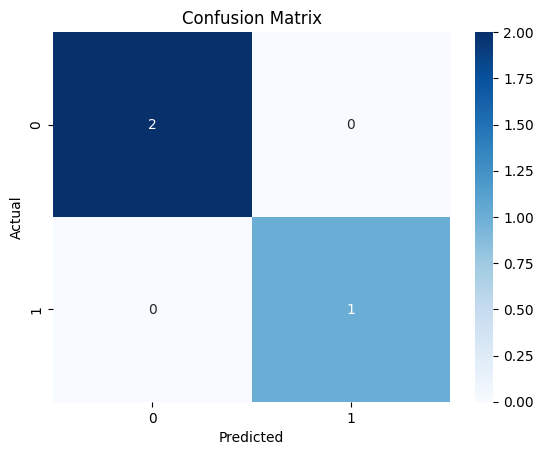

In [ ]:
# 1. Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load Dataset
df = pd.read_csv("/content/DatasetCapstoneProject4.csv")
print(df.head())

# 3. Dataset Information
print(df.info())
print(df.describe())

# 4. Drop Sign_ID (not useful for prediction)
df = df.drop("Sign_ID", axis=1)

# 5. Define Features and Target
X = df.drop("Stop_Sign", axis=1)
y = df["Stop_Sign"]

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

# 7. Create Perceptron Model
model = Perceptron()

# 8. Train Model
model.fit(X_train,y_train)

# 9. Predictions
y_pred = model.predict(X_test)

# 10. Model Evaluation
print("\nModel Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

# 11. Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure()
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()